## AXA Data Challenge - Data Cleaning
We have two data sets from a motor insurance describing the occurrence and amount of claims. We want to figure out which features influence the amount of the claims. Features are usually attributes that describe the driver or the car, e.g. the age of the driver, the vehicle power, and so on... 

In this you notebook you will learn how to read in data sets, analyze them for errors in the data and check for hidden patterns in the data.

 - insurance_claims_freq.csv
 - insurance_claims_sev.csv


We will start by reading the dataset insurance_claims_freq.csv.

- **IDPol:** Policy ID, used to link to severity data set
- **ClaimNb:** Number of claims that occurred for the policy
- **VehPower:** Car power, in categorical format; 1 is lowest, 8 is highest power
- **VehAge:** Car age, in years
- **VehBrand:** Car brand, in categorical format
- **VechGas:** Fuel type, in categorical format (Regular or Diesel)
- **DriverBirthDate:** The Birth Date of the Driver
- **BonusMalus:** Bonus / Malus rating, <100 means bonus, >100 means malus, in continous value format
- **Region:** Policy region in France, in categorical format
- **Density:** Density rating, number of inhabitants per km^2, in continous value format
- **Area:** Density rating of the area car driver lives in, in categorical format

    | Area Code  | Density in km^2  |
    |------------|------------------|
    | **A**  | 1-50 |
    | **B**  | 50-100 |
    | **C**  | 100-500 |
    | **D**  | 500-2000 |
    | **E**  | 2001-9850 |
    | **F**  | 10008-27000 |


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [23]:
# Read the frequency data and check it out
df1 = pd.read_csv("../data/new/adapted/insurance_claims_freq.csv")
df1.head()

,IDpol,ClaimNb,Area,VehPower,VehAge,BonusMalus,VehBrand,VehGas,Density,Region,DriverBirthDate
0,1.0,1,D,5,0,50,B12,Regular,1217,R82,1970-04-25
1,3.0,1,D,5,0,50,B12,Regular,1217,R82,1969-07-17
2,5.0,1,B,6,2,50,B12,Diesel,54,R22,1973-01-11
3,10.0,1,B,7,0,50,B12,Diesel,76,R72,1979-06-30
4,11.0,1,B,7,0,50,B12,Diesel,76,R72,1979-07-14


In [24]:
# how many rows and columns do we have, are they unique?
print(df1.shape) #(677608, 11)
print(df1.nunique())

(677608, 11)
IDpol              677608
ClaimNb                11
Area                    6
VehPower               12
VehAge                 78
BonusMalus            115
VehBrand               11
VehGas                  2
Density              1607
Region                 22
DriverBirthDate     25741
dtype: int64


In [25]:
# check otu the data types for the columns, is the IDpol data type correct?
print(df1.dtypes)
df1["IDpol"] = df1["IDpol"].astype(int)
print(df1.dtypes)

IDpol              float64
ClaimNb              int64
Area                object
VehPower             int64
VehAge               int64
BonusMalus           int64
VehBrand            object
VehGas              object
Density              int64
Region              object
DriverBirthDate     object
dtype: object
IDpol               int64
ClaimNb             int64
Area               object
VehPower            int64
VehAge              int64
BonusMalus          int64
VehBrand           object
VehGas             object
Density             int64
Region             object
DriverBirthDate    object
dtype: object


In [26]:
# how many different claims do we have? what is the maximum and what is the minimum?
df1['ClaimNb'].value_counts().sort_index()

ClaimNb
0     643570
1      32158
2       1782
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

In [27]:
def calculate_age_at(date_series):
    """
    Calculates the age in years for reference date 2025-07-16 for a pandas series with birth dates.
    
    Parameters:
    - date_series: pd.Series mit datetime64[ns]
    
    Returns:
    - pd.Series age in years
    """
    reference_date = pd.Timestamp('2025-07-16')
    birth_dates = pd.to_datetime(date_series)
    
    # Check if the birthday has not yet occurred this year
    not_had_birthday = ( (birth_dates.dt.month > reference_date.month) | 
                         ((birth_dates.dt.month == reference_date.month) & (birth_dates.dt.day > reference_date.day)) )
    
    age = reference_date.year - birth_dates.dt.year - not_had_birthday.astype(int)
    
    return age.astype(int)

In [28]:
# Calculate the driver's age
df1['DrivAge'] = calculate_age_at(df1['DriverBirthDate'])

In [29]:
df1[["DrivAge","DriverBirthDate"]]

,DrivAge,DriverBirthDate
0,55,1970-04-25
1,55,1969-07-17
2,52,1973-01-11
3,46,1979-06-30
4,46,1979-07-14
...,...,...
677603,54,1970-09-24
677604,41,1983-08-04
677605,45,1979-09-25
677606,60,1965-06-19


In [30]:
def plot_scatter(df):
    plt.scatter(df['DrivAge'], df['ClaimNb'])
    plt.xlabel('Age')
    plt.ylabel('Number of claims')
    plt.title('Age vs. number of claims')
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.show()

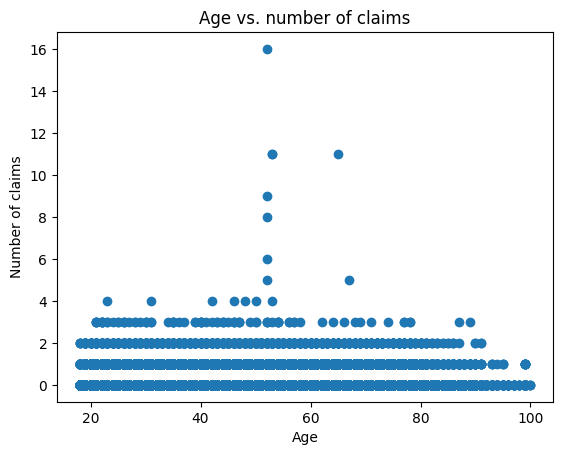

In [31]:
plot_scatter(df1)

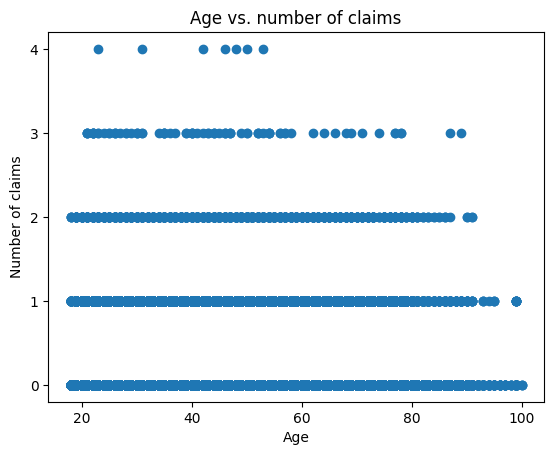

In [32]:
#cutte claims> 4 weg
df1 = df1[df1["ClaimNb"] <= 4]
# execute the graphic again
plot_scatter(df1)

In [33]:
# Write insurance_claims_freq
df1.to_csv("../data/new/sample_solution/insurance_claims_freq.csv", index=False)

# Severity data
columns:
    

In [52]:
# Read the severity data and check it out
df2 = pd.read_csv("../data/new/adapted/insurance_claims_sev.csv")
df2.to_csv("../data/new/sample_solution/insurance_claims_sev.csv", index=False)
df2.head()

,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00


In [35]:
print(df2.shape) #26421
print(df2.nunique()) # 24922

(26421, 2)
IDpol          24922
ClaimAmount    12236
dtype: int64


In [36]:
df2 = df2[df2['IDpol'].isin(df1['IDpol'])] # we can see that 26421 we have in df2, but only 26350 of them, are in df1 how can that be? => we deleted noclaims more than 4

In [37]:
df2

,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00
...,...,...
26408,3251681,543.97
26409,3251500,752.11
26410,2227090,2202.89
26419,2222064,767.55


In [38]:
id_counts = df2.groupby('IDpol').size().reset_index(name='count')

In [39]:
result = id_counts.merge(df1[['IDpol', 'ClaimNb']], on='IDpol', how='left')

In [40]:
df1[~df1['IDpol'].isin(result['IDpol']) & df1["ClaimNb"]>0] # we have lots of polnrs in df1 with at least one claim that are not in df2; we will ignore this; this is just incomplete data

,IDpol,ClaimNb,Area,VehPower,VehAge,BonusMalus,VehBrand,VehGas,Density,Region,DriverBirthDate,DrivAge
0,1,1,D,5,0,50,B12,Regular,1217,R82,1970-04-25,55
1,3,1,D,5,0,50,B12,Regular,1217,R82,1969-07-17,55
2,5,1,B,6,2,50,B12,Diesel,54,R22,1973-01-11,52
3,10,1,B,7,0,50,B12,Diesel,76,R72,1979-06-30,46
4,11,1,B,7,0,50,B12,Diesel,76,R72,1979-07-14,46
...,...,...,...,...,...,...,...,...,...,...,...,...
533218,4124801,1,C,5,5,50,B5,Regular,242,R82,1979-11-28,45
534941,4126524,1,D,5,6,54,B2,Regular,1282,R31,1982-01-25,43
545002,4136585,1,C,6,12,50,B1,Diesel,304,R11,1981-02-21,44
594883,4186466,1,D,10,10,50,B13,Regular,1313,R24,1962-07-08,63


In [41]:
df2[df2['IDpol'].isin(df1['IDpol'])]

,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00
...,...,...
26408,3251681,543.97
26409,3251500,752.11
26410,2227090,2202.89
26419,2222064,767.55


In [51]:
df_merged = df2.merge(df1.drop(columns=['ClaimNb']), on="IDpol", how="left")
df_merged.to_csv("../data/new/sample_solution/insurance_claims_freqsev.csv", index=False)